<a href="https://colab.research.google.com/github/spycoder01/Employee-Attrition-Prediction/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TASK 1** -
Data Loading & Exploration

In [110]:
import numpy as np
import pandas as pd

df = pd.read_csv('/content/WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [2]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [3]:
df.shape

(1470, 35)

In [4]:
# no. of rows = 1470
# no. of columns = 35

In [5]:
# Target column
print(df['Attrition'].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [6]:
# so there are total of 237 employee left the company and 1233 stayed

In [7]:
# Attrition rate

attrition_count = df['Attrition'].value_counts()

attrition_rate = (attrition_count['Yes']/(df.shape[0]))*100
print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.12%


In [8]:
# Observation
# The dataset is imbalanced. 16% of the employee left the company while 84% stayed.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [10]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

print('Total Num col:', len(num_cols))
print('Total Cat col:', len(cat_cols))

Total Num col: 26
Total Cat col: 9


**TASK 2** -
Data Cleaning and Preprocessing

In [11]:
print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [12]:
# There are no missing/Null values in the columns

In [13]:
pd.set_option('display.max_columns', None) #To check all columns
df.sample(3)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1305,54,No,Travel_Rarely,431,Research & Development,7,4,Medical,1,1830,4,Female,68,3,2,Research Scientist,4,Married,6854,15696,4,Y,No,15,3,2,80,1,14,2,2,7,1,1,7
929,28,No,Travel_Frequently,193,Research & Development,2,3,Life Sciences,1,1296,4,Male,52,2,1,Laboratory Technician,4,Married,3867,14222,1,Y,Yes,12,3,2,80,1,2,2,3,2,2,2,2
603,45,No,Travel_Rarely,252,Research & Development,2,3,Life Sciences,1,834,2,Female,95,2,1,Research Scientist,3,Single,2274,6153,1,Y,No,14,3,4,80,0,1,3,3,1,0,0,0


In [14]:
df = df.drop(columns=['EmployeeNumber','EmployeeCount','StandardHours','Over18'])

In [15]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2


In [16]:
df.shape # 4 columns get dropped

(1470, 31)

In [17]:
df['Attrition'] = df['Attrition'].replace({'Yes': 1, 'No': 0}).astype(int)

/tmp/ipykernel_555/1915115092.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Attrition'] = df['Attrition'].replace({'Yes': 1, 'No': 0}).astype(int)


In [18]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2


In [19]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [20]:
X.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5
1,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7
2,37,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0
3,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0
4,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2


In [21]:
y.head()

,Attrition
0,1
1,0
2,1
3,0
4,0


In [22]:
print(y.value_counts())

Attrition
0    1233
1     237
Name: count, dtype: int64


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   int64 
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

In [24]:
categorical_cols = X.select_dtypes(
    include="object"
).columns

X_encoded = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True,
    dtype = int
)

In [25]:
categorical_cols

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')

In [26]:
X_encoded.head(3)

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,2,94,3,2,4,5993,19479,8,11,3,1,0,8,0,1,6,4,0,5,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1
1,49,279,8,1,3,61,2,2,2,5130,24907,1,23,4,4,1,10,3,3,10,7,1,7,1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0
2,37,1373,2,2,4,92,2,1,3,2090,2396,6,15,3,2,0,7,3,3,0,0,0,0,0,1,1,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,1,1


In [27]:
# Standard Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_encoded)

**TASK 3** - Exploratory Data Analysis

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
dept_attrition = (
    pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
    .groupby("Department")["Attrition"]
    .apply(lambda x: (x=="Yes").mean()*100)
    .sort_values(ascending=False)
)

dept_attrition

,Attrition
Department,
Sales,20.627803
Human Resources,19.047619
Research & Development,13.839750


In [30]:
# Sales department having higher attrition rate (20.6%)

In [31]:
job_attrition = (
    pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
    .groupby("JobRole")["Attrition"]
    .apply(lambda x:(x=="Yes").mean()*100)
    .sort_values(ascending=False)
)

job_attrition

,Attrition
JobRole,
Sales Representative,39.759036
Laboratory Technician,23.938224
Human Resources,23.076923
Sales Executive,17.484663
Research Scientist,16.095890
Manufacturing Director,6.896552
Healthcare Representative,6.870229
Manager,4.901961
Research Director,2.500000


In [32]:
# Sales Representative role having higher exit rate (39.7%)

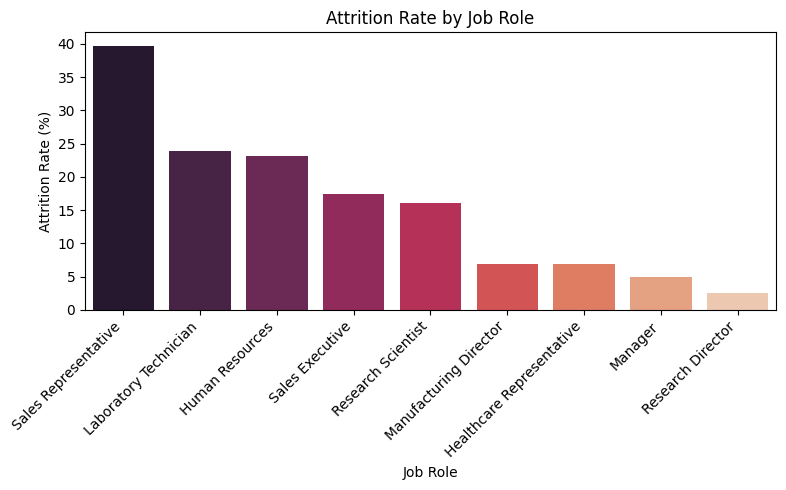

In [103]:
plt.figure(figsize=(8,5))
sns.barplot(x=job_attrition.index, y=job_attrition.values, hue=job_attrition.index, palette='rocket')
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")
plt.title("Attrition Rate by Job Role")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

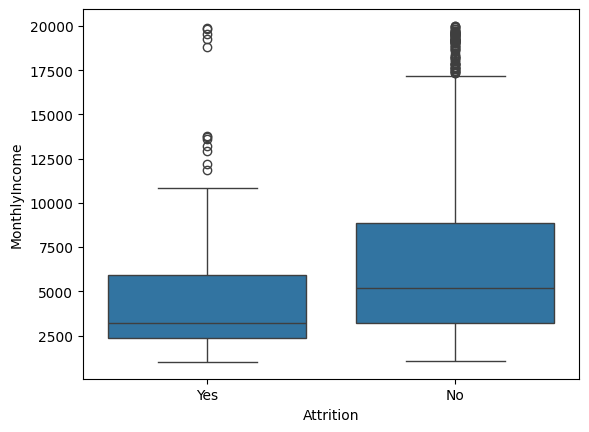

In [34]:
sns.boxplot(
    data=pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv"),
    x="Attrition",
    y="MonthlyIncome"
)
plt.show()

Employees who left the company generally had lower monthly incomes than those who stayed, as indicated by the lower median salary. However, the presence of several high-income employees among those who left suggests that salary alone does not explain attrition. Other factors, such as overtime, job satisfaction, work-life balance, and career growth opportunities, are also likely to influence an employee's decision to leave.

In [35]:
wlb_attrition = (
    df.groupby('WorkLifeBalance')['Attrition']
      .mean() * 100
)

wlb_attrition

,Attrition
WorkLifeBalance,
1,31.250000
2,16.860465
3,14.221725
4,17.647059


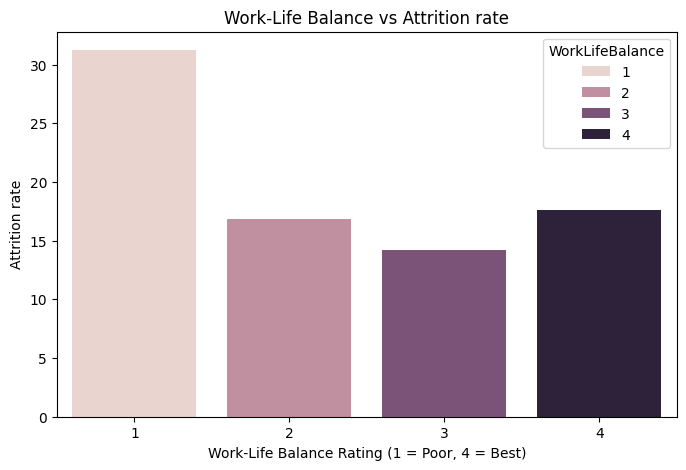

In [107]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=wlb_attrition.index,
    y=wlb_attrition.values,
    hue=wlb_attrition.index,
)

plt.title('Work-Life Balance vs Attrition rate')
plt.xlabel('Work-Life Balance Rating (1 = Poor, 4 = Best)')
plt.ylabel('Attrition rate')
plt.show()

From the above plot, it can be analyzed that the attrition rate is higher for poor work-life balance. As the work-life balance rating improves, the attrition rate generally decreases. However, there is an anomaly for the best work-life balance rating (4), where the attrition rate increases again. This suggests that other factors may also affect the attrition rate in this specific category.

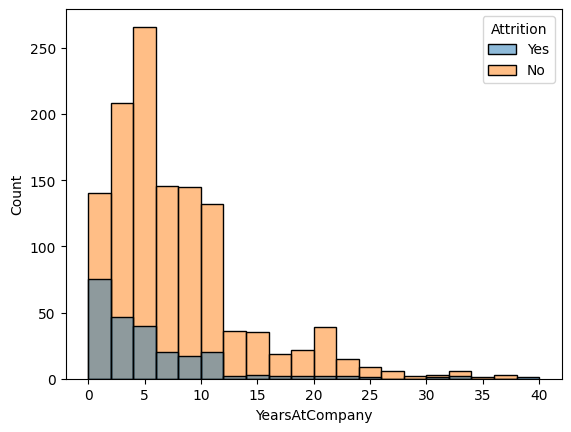

In [76]:
sns.histplot(
    data=pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv"),
    x="YearsAtCompany",
    hue="Attrition",
    bins=20
)
plt.show()

In [38]:
# From the above plot, it can be evaluated that more experienced employee having lower attrition rate compared with the low experienced employee

1. Sales department has the highest attrition rate (20.6%), indicating retention issues in customer-facing roles.

2. Sales Representatives experience extremely high attrition (39.8%), nearly double the company average.

3. Employees with lower monthly income are more likely to leave than high-income employees.

4. Employees reporting poor work-life balance show noticeably higher attrition.

5. Most exits occur during the first few years of employment, suggesting onboarding and early-career engagement issues.

**Task 4** — Model Building & Comparison

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [56]:
# Scale
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [57]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(
    #class_weight='balanced',
    max_iter=2000
)

lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=2000)

In [58]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    #class_weight="balanced"
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [59]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()

gb.fit(X_train, y_train)

GradientBoostingClassifier()

Task 5 - Model Evaluation

In [60]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

In [62]:
def evaluate(model, X, y):

    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X)[:,1]
    else:
        prob = None

    return {
        "Precision": precision_score(y,model.predict(X)),
        "Recall": recall_score(y,model.predict(X)),
        "F1": f1_score(y,model.predict(X)),
        "ROC_AUC": roc_auc_score(y,prob)
    }

In [63]:
results = pd.DataFrame([
    evaluate(lr,X_test_scaled,y_test),
    evaluate(rf,X_test,y_test),
    evaluate(gb,X_test,y_test)
],
index=[
    "Logistic Regression",
    "Random Forest",
    "Gradient Boosting"
])

results

,Precision,Recall,F1,ROC_AUC
Logistic Regression,0.548387,0.435897,0.485714,0.790246
Random Forest,0.800000,0.102564,0.181818,0.753846
Gradient Boosting,0.500000,0.179487,0.264151,0.780995


In [47]:
# Here Logistic Regression perform better beacuse it having a higest ROC_AUC score also achieve highest Recall and Precision score

In [64]:
importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": lr.coef_[0]
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
43,OverTime_Yes,0.975324
34,JobRole_Laboratory Technician,0.780808
23,BusinessTravel_Travel_Frequently,0.717950
19,YearsAtCompany,0.668289
42,MaritalStatus_Single,0.625524
11,NumCompaniesWorked,0.509736
40,JobRole_Sales Representative,0.506542
21,YearsSinceLastPromotion,0.500860
24,BusinessTravel_Travel_Rarely,0.441246
38,JobRole_Research Scientist,0.398999


**Task 6** - Visualization

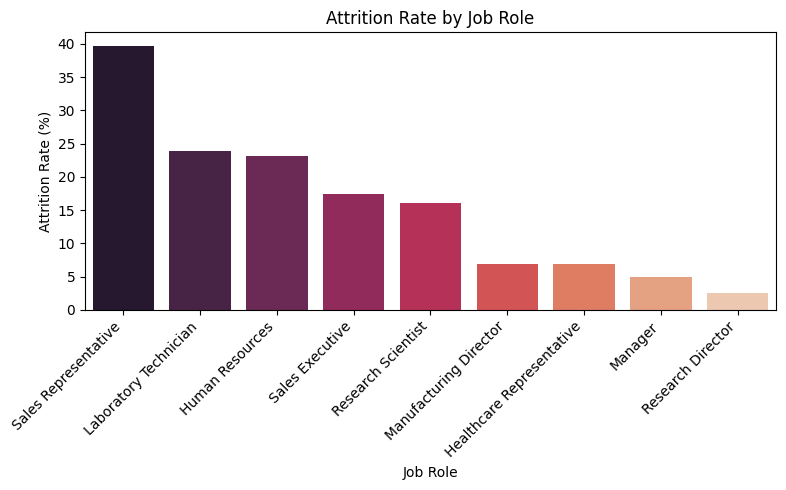

In [71]:
# Attrition rate by Department and Job Role

plt.figure(figsize=(8,5))
sns.barplot(x=job_attrition.index, y=job_attrition.values, hue=job_attrition.index, palette='rocket')

plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")
plt.title("Attrition Rate by Job Role")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

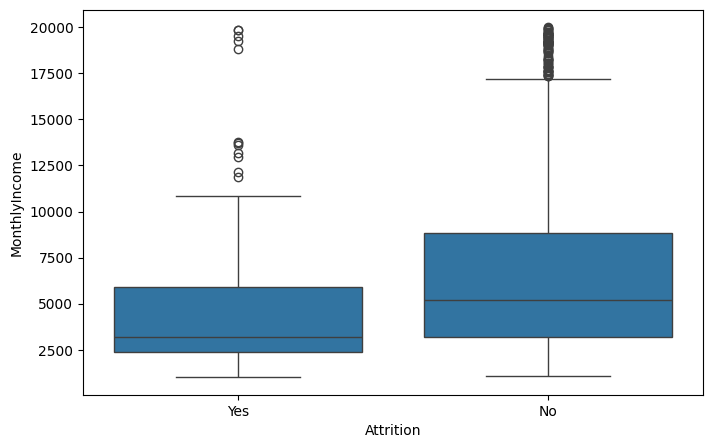

In [90]:
# Monthly Income of employees who left vs stayed

plt.figure(figsize=(8,5))
sns.boxplot(
    data=pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv"),
    x = "Attrition",
    y = "MonthlyIncome",
)
plt.show()

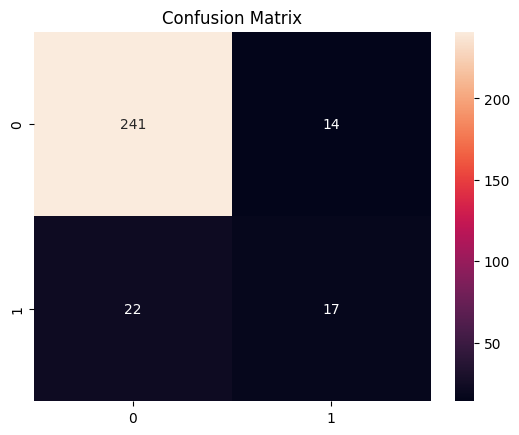

In [91]:
cm = confusion_matrix(
    y_test,
    lr.predict(X_test_scaled)
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.show()

In [92]:
# Here TN(Truely Negative) = 241
# so total of 241 employees get correctly classified by the model

# Here TP(Truely Possitive) = 17
# so total of 17 employees get correctly classified by the model

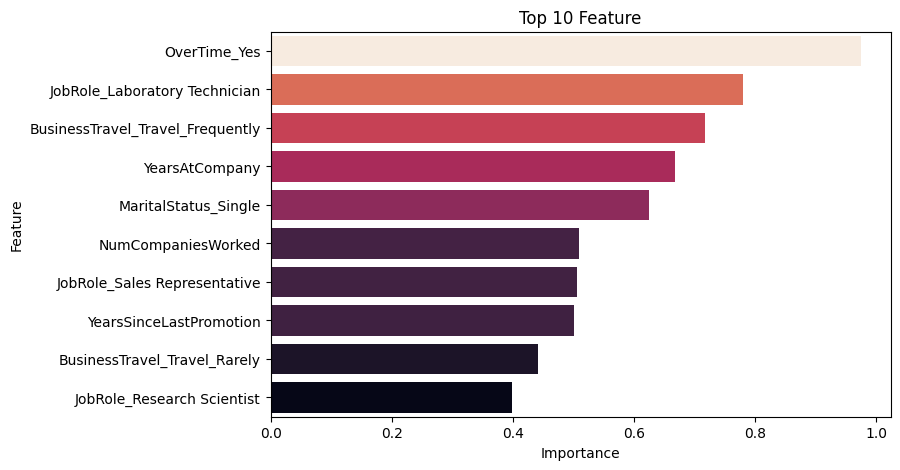

In [101]:
# Top 10 Feature Importances

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature",
    hue="Importance", palette = 'rocket', legend=False
)

plt.title("Top 10 Feature")
plt.show()

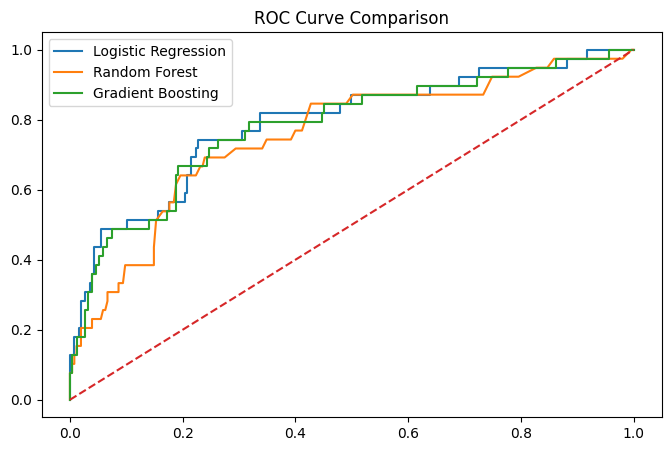

In [102]:
from sklearn.metrics import roc_curve

models = {
    "Logistic Regression": (lr, X_test_scaled),
    "Random Forest": (rf, X_test),
    "Gradient Boosting": (gb, X_test)
}

plt.figure(figsize=(8,5))

for name, (model, X_data) in models.items():

    prob = model.predict_proba(X_data)[:,1]

    fpr,tpr,_ = roc_curve(y_test,prob)

    plt.plot(fpr,tpr,label=name)

plt.plot([0,1],[0,1],'--')

plt.legend()
plt.title("ROC Curve Comparison")
plt.show()

**Task 7** - HR Insights & Business Recommendations

#### HR Insights:

1.  **Overall Attrition:** Moderate attrition rate (16.12%) with imbalances in Sales (20.6%) and HR (19.05%) departments, and high rates among Sales Representatives (40%) and Laboratory Technicians (24%).
2.  **Compensation:** Lower monthly income correlates with higher attrition, suggesting compensation as a factor.
3.  **Work-Life Balance (WLB):** Poor WLB is a strong attrition predictor (31.25%). An anomaly exists for the 'best' WLB, implying other factors at play.
4.  **Early Career Turnover:** Significant attrition occurs within the first few years, pointing to onboarding/integration issues.
5.  **Key Predictors:** Overtime, YearsAtCompany (inversely), and specific job roles (Lab Tech, Sales Rep) are strong predictors.

### Business Recommendations:

1.  **Targeted Retention:** Implement strategies for Sales Roles (e.g., compensation review, mentorship) and other high-attrition roles.
2.  **Competitive Compensation:** Review salary bands, especially for roles with high turnover and lower incomes.
3.  **Improve Work-Life Balance:** Develop and promote WLB programs, address root causes for poor WLB, and investigate anomalies in 'best' WLB scenarios.
4.  **Strengthen Onboarding & Development:** Enhance early career programs focusing on integration, skill development, and clear career paths.
5.  **Manage Overtime:** Establish clear overtime policies and address systemic issues leading to excessive extended hours.
6.  **Career Growth:** Provide clear opportunities for skill development and career advancement.
7.  **Manager Training:** Train managers in high-attrition departments on effective team management and fostering positive environments.

In [112]:
import numpy
import pandas as pd
import matplotlib
import seaborn
import sklearn

print("NumPy:", numpy.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Seaborn:", seaborn.__version__)
print("Scikit-learn:", sklearn.__version__)

NumPy: 2.0.2
Pandas: 2.2.2
Matplotlib: 3.10.0
Seaborn: 0.13.2
Scikit-learn: 1.6.1
